In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SEED = 42
PCT_COLS = [
    'pct_Cereales', 'pct_Tuberculos', 'pct_Azucares',
    'pct_Aceites_Grasas', 'pct_Carnes', 'pct_Lacteos_Huevos', 'pct_Frutas_Verduras'
]

print('Librerías OK')

Librerías OK


## 1. Carga y validación

In [2]:
df = pd.read_parquet('../processed/02_dataset_final.parquet')

print(f'Shape: {df.shape}')
print(f'Países: {df["Area"].nunique()} | Años: {sorted(df["Year"].unique())}')
print(f'Nulos: {df.isnull().sum().sum()}')

# Validar que pct_ suman 1.0
sumas = df[PCT_COLS].sum(axis=1)
assert sumas.max() < 1.0001 and sumas.min() > 0.9999, 'ERROR: pct_ no suman 1.0'
print(f'pct_ suman 1.0 ✅ (min={sumas.min():.6f} / max={sumas.max():.6f})')

df.head(3)

Shape: (390, 13)
Países: 30 | Años: [np.int16(2010), np.int16(2011), np.int16(2012), np.int16(2013), np.int16(2014), np.int16(2015), np.int16(2016), np.int16(2017), np.int16(2018), np.int16(2019), np.int16(2020), np.int16(2021), np.int16(2022)]
Nulos: 0
pct_ suman 1.0 ✅ (min=1.000000 / max=1.000000)


,Area,Year,pct_Cereales,pct_Tuberculos,pct_Azucares,pct_Aceites_Grasas,pct_Carnes,pct_Lacteos_Huevos,pct_Frutas_Verduras,Total_DES_Kcal,Ratio_Proteina_AV,CO2eq_t_per_capita,Food_CPI
0,Argentina,2010,0.348980,0.029218,0.144451,0.094498,0.157141,0.175655,0.050056,3223.020020,0.777102,7.059479,58.802021
1,Argentina,2011,0.340215,0.029444,0.145032,0.098630,0.159451,0.171333,0.055895,3201.359863,0.777304,6.199139,63.906952
2,Argentina,2012,0.320530,0.029209,0.141830,0.115709,0.162534,0.176849,0.053338,3232.240234,0.841984,6.208147,70.440468


## 2. Preparación de features

Las pct_ ya suman 1.0 pero sus varianzas son distintas (Cereales llega a 0.70, Tubérculos rara vez supera 0.15).  
Sin escalar, K-Means pesa más los ejes con mayor varianza. StandardScaler iguala la influencia de cada macrocategoría.

In [3]:
X_raw = df[PCT_COLS].values.astype(np.float64)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f'X_scaled shape: {X_scaled.shape}')
print(f'Media por columna (debe ser ~0): {X_scaled.mean(axis=0).round(3)}')
print(f'Std por columna  (debe ser ~1): {X_scaled.std(axis=0).round(3)}')

X_scaled shape: (390, 7)
Media por columna (debe ser ~0): [-0.  0.  0. -0. -0.  0.  0.]
Std por columna  (debe ser ~1): [1. 1. 1. 1. 1. 1. 1.]


## 3. K-Means — barrido K = 3..6

Criterios de selección del K óptimo:
- **Silhouette Score** — maximizar (rango −1 a 1, queremos ≥ 0.25)
- **Davies-Bouldin Index** — minimizar (0 es perfecto, sin cota superior)
- **Inertia** — referencia para curva de codo (no es criterio de selección principal)

In [4]:
resultados = []

for k in range(3, 7):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20, max_iter=500)
    labels = km.fit_predict(X_scaled)
    
    sil  = silhouette_score(X_scaled, labels)
    db   = davies_bouldin_score(X_scaled, labels)
    inertia = km.inertia_
    
    resultados.append({
        'K': k,
        'Silhouette': round(sil, 4),
        'Davies_Bouldin': round(db, 4),
        'Inertia': round(inertia, 2),
        'modelo': km,
        'labels': labels
    })
    print(f'K={k} | Silhouette={sil:.4f} | Davies-Bouldin={db:.4f} | Inertia={inertia:.1f}')

df_res = pd.DataFrame([{k: v for k, v in r.items() if k not in ('modelo', 'labels')} for r in resultados])
display(df_res)

K=3 | Silhouette=0.3995 | Davies-Bouldin=0.9083 | Inertia=1371.2
K=4 | Silhouette=0.3482 | Davies-Bouldin=1.1284 | Inertia=1122.7
K=5 | Silhouette=0.3419 | Davies-Bouldin=1.1670 | Inertia=970.3
K=6 | Silhouette=0.3587 | Davies-Bouldin=1.1240 | Inertia=848.9


,K,Silhouette,Davies_Bouldin,Inertia
0,3,0.3995,0.9083,1371.18
1,4,0.3482,1.1284,1122.72
2,5,0.3419,1.1670,970.35
3,6,0.3587,1.1240,848.92


## 4. Visualización de métricas

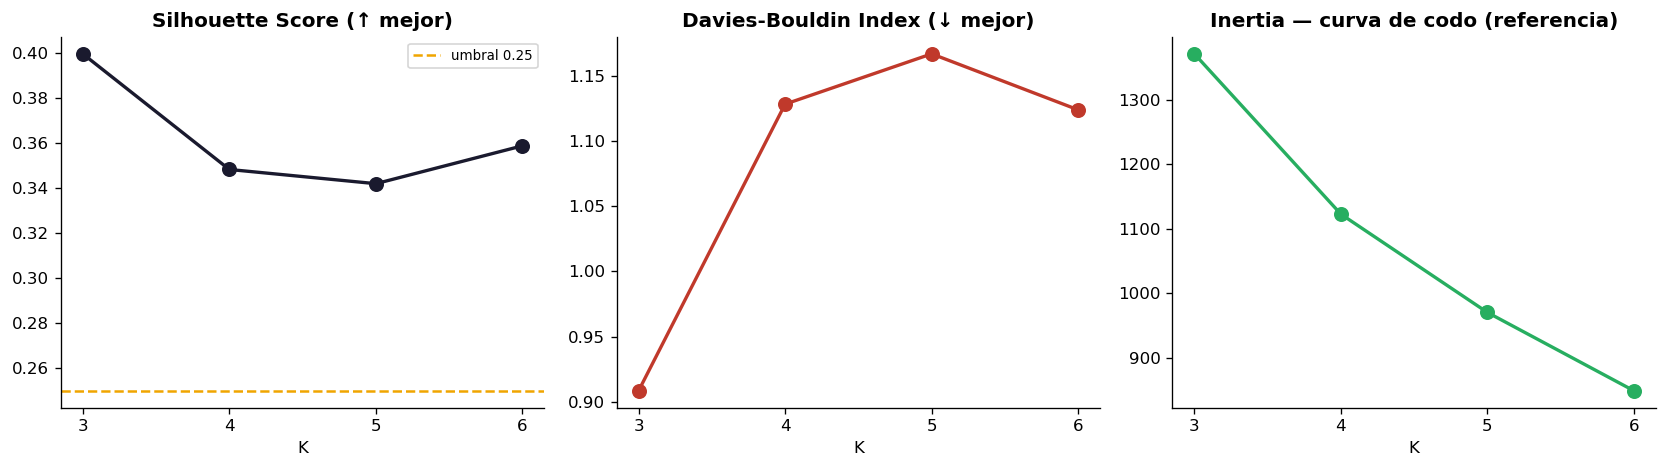

Gráfico guardado en memoria/


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ks = df_res['K'].tolist()

# Silhouette
axes[0].plot(ks, df_res['Silhouette'], 'o-', color='#1a1a2e', lw=2, ms=8)
axes[0].axhline(0.25, color='#f0a500', ls='--', lw=1.5, label='umbral 0.25')
axes[0].set_title('Silhouette Score (↑ mejor)', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_xticks(ks)
axes[0].legend(fontsize=8)

# Davies-Bouldin
axes[1].plot(ks, df_res['Davies_Bouldin'], 'o-', color='#c0392b', lw=2, ms=8)
axes[1].set_title('Davies-Bouldin Index (↓ mejor)', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_xticks(ks)

# Inertia (codo)
axes[2].plot(ks, df_res['Inertia'], 'o-', color='#27ae60', lw=2, ms=8)
axes[2].set_title('Inertia — curva de codo (referencia)', fontweight='bold')
axes[2].set_xlabel('K'); axes[2].set_xticks(ks)

plt.tight_layout()
plt.savefig('../memoria/03_metricas_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado en memoria/')

## 5. Selección del K óptimo

In [6]:
SILHOUETTE_MINIMO = 0.25

mejor = max(resultados, key=lambda r: r['Silhouette'])

print(f"K óptimo por Silhouette máximo: K={mejor['K']}")
print(f"  Silhouette  = {mejor['Silhouette']}  (umbral mínimo: {SILHOUETTE_MINIMO})")
print(f"  Davies-Bouldin = {mejor['Davies_Bouldin']}")

if mejor['Silhouette'] >= SILHOUETTE_MINIMO:
    print(f"\n✅ Silhouette ≥ {SILHOUETTE_MINIMO} — K-Means válido. Procedemos con K={mejor['K']}.")
    USAR_HDBSCAN = False
else:
    print(f"\n⚠️  Silhouette < {SILHOUETTE_MINIMO} en todos los K — activando fallback HDBSCAN.")
    USAR_HDBSCAN = True

K_OPTIMO = mejor['K']
labels_finales = mejor['labels']

K óptimo por Silhouette máximo: K=3
  Silhouette  = 0.3995  (umbral mínimo: 0.25)
  Davies-Bouldin = 0.9083

✅ Silhouette ≥ 0.25 — K-Means válido. Procedemos con K=3.


## 6. Fallback HDBSCAN (solo si Silhouette < 0.25 en todos los K)

> Esta celda solo es relevante si `USAR_HDBSCAN = True` arriba.

In [7]:
if USAR_HDBSCAN:
    try:
        import hdbscan
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'hdbscan', '-q'])
        import hdbscan

    hdb = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=3, metric='euclidean')
    labels_hdb = hdb.fit_predict(X_scaled)
    
    n_clusters_hdb = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
    n_ruido = (labels_hdb == -1).sum()
    
    print(f'HDBSCAN → {n_clusters_hdb} clústeres | {n_ruido} puntos ruido ({n_ruido/len(labels_hdb)*100:.1f}%)')
    
    if n_clusters_hdb >= 2:
        # Silhouette solo sobre puntos no-ruido
        mask = labels_hdb != -1
        sil_hdb = silhouette_score(X_scaled[mask], labels_hdb[mask]) if mask.sum() > 1 else 0
        print(f'Silhouette HDBSCAN (sin ruido): {sil_hdb:.4f}')
        labels_finales = labels_hdb
        K_OPTIMO = n_clusters_hdb
    else:
        print('HDBSCAN no separó los datos. Usar K-Means con el mejor K igualmente.')
        labels_finales = mejor['labels']
else:
    print('HDBSCAN no necesario — K-Means superó el umbral de Silhouette.')

HDBSCAN no necesario — K-Means superó el umbral de Silhouette.


## 7. Análisis de centroides y naming narrativo

Los centroides se invierten al espacio original (sin escalar) para poder interpretarlos como porcentajes reales de la dieta.

In [8]:
# Añadir cluster al dataframe
df['cluster_id'] = labels_finales

# Calcular centroides en espacio original (pct_, sin escalar)
centroides = df.groupby('cluster_id')[PCT_COLS].mean()
centroides.columns = [c.replace('pct_', '') for c in centroides.columns]

print(f'=== Centroides (% dietario medio por clúster) === K={K_OPTIMO}')
print(centroides.round(3).to_string())
print()

# Países representativos de cada clúster (los más cercanos al centroide)
for cid in sorted(df['cluster_id'].unique()):
    if cid == -1:  # ruido HDBSCAN
        continue
    subset = df[df['cluster_id'] == cid].copy()
    paises = subset['Area'].value_counts().head(5).index.tolist()
    print(f'Clúster {cid}: {subset["Area"].nunique()} países | ejemplos: {paises}')

=== Centroides (% dietario medio por clúster) === K=3
            Cereales  Tuberculos  Azucares  Aceites_Grasas  Carnes  Lacteos_Huevos  Frutas_Verduras
cluster_id                                                                                         
0              0.314       0.034     0.121           0.145   0.117           0.200            0.069
1              0.450       0.282     0.044           0.143   0.025           0.018            0.037
2              0.596       0.039     0.085           0.089   0.059           0.081            0.052

Clúster 0: 18 países | ejemplos: ['Argentina', 'Australia', 'United Kingdom of Great Britain and Northern Ireland', 'Spain', 'Saudi Arabia']
Clúster 1: 1 países | ejemplos: ['Nigeria']
Clúster 2: 12 países | ejemplos: ['Bangladesh', 'China, mainland', 'Egypt', 'Ethiopia', 'India']


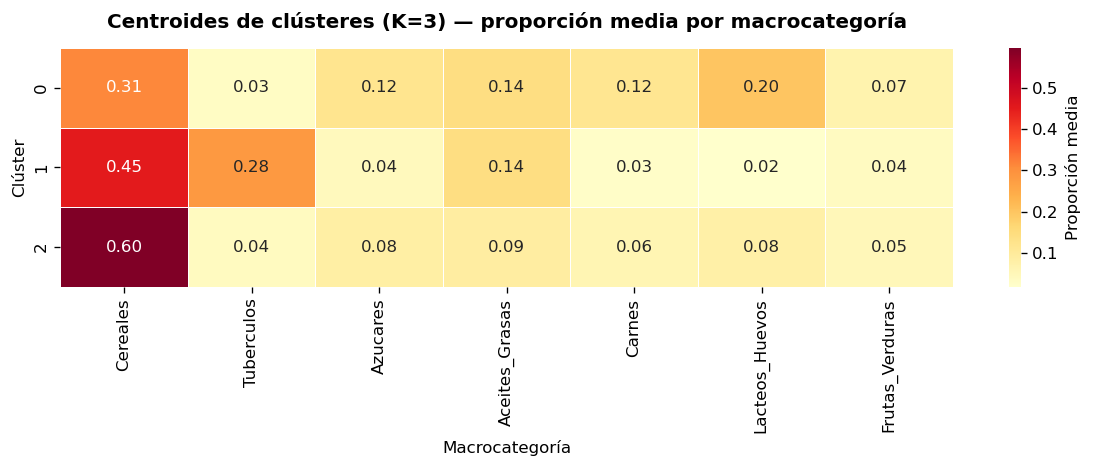

In [9]:
# Heatmap de centroides
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    centroides,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Proporción media'}
)
ax.set_title(f'Centroides de clústeres (K={K_OPTIMO}) — proporción media por macrocategoría', fontweight='bold', pad=12)
ax.set_xlabel('Macrocategoría')
ax.set_ylabel('Clúster')
plt.tight_layout()
plt.savefig('../memoria/03_heatmap_centroides.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ─────────────────────────────────────────────────────────────────
# NAMING NARRATIVO — editar aquí tras revisar el heatmap anterior
# ─────────────────────────────────────────────────────────────────
# Ejemplos orientativos para K=4 (ajustar según resultado real):
#
#   0 → 'Dieta Cereal-Dependiente'     (Cereales > 50%, bajo en Carnes/Lácteos)
#   1 → 'Dieta Occidental Proteica'    (Carnes + Lácteos dominantes, Cereales < 35%)
#   2 → 'Dieta Mediterránea-Diversa'   (Aceites altos, balance entre categorías)
#   3 → 'Dieta de Transición'          (mix intermedio, varianza alta intra-clúster)
#
# INSTRUCCIÓN: mira el heatmap, identifica el rasgo dominante de cada clúster
# y pon un nombre que capture ESA feature + contexto geográfico si aplica.

NOMBRES_CLUSTERS = {
    # cluster_id (int) : 'Nombre narrativo'
    # TODO: rellenar después de revisar el heatmap
    0: 'Clúster 0 — (pendiente nombrar)',
    1: 'Clúster 1 — (pendiente nombrar)',
    2: 'Clúster 2 — (pendiente nombrar)',
    3: 'Clúster 3 — (pendiente nombrar)',
    # Si K=3, eliminar la línea del 3
    # Si HDBSCAN, añadir -1: 'Ruido / Dieta Atípica'
}

# Aplicar solo los K que existan en el resultado real
ids_reales = sorted(df['cluster_id'].unique())
nombres_filtrados = {k: v for k, v in NOMBRES_CLUSTERS.items() if k in ids_reales}

df['cluster_nombre'] = df['cluster_id'].map(nombres_filtrados).fillna('Sin nombre')
print('Distribución de clústeres:')
print(df.groupby(['cluster_id', 'cluster_nombre'])['Area'].nunique().rename('n_países'))
print(f'\nTotal filas con nombre asignado: {(df["cluster_nombre"] != "Sin nombre").sum()} / {len(df)}')

Distribución de clústeres:
cluster_id  cluster_nombre                 
0           Clúster 0 — (pendiente nombrar)    18
1           Clúster 1 — (pendiente nombrar)     1
2           Clúster 2 — (pendiente nombrar)    12
Name: n_países, dtype: int64

Total filas con nombre asignado: 390 / 390


## 8. Estabilidad temporal

¿Cambia el clúster de un país a lo largo de los años?  
Una dieta estructural debería ser estable. Alta inestabilidad puede indicar K demasiado alto o features que capturan ruido interanual.

In [11]:
# Porcentaje de años en el clúster modal (el más frecuente) por país
estabilidad = []
for pais, grupo in df.groupby('Area'):
    modal = grupo['cluster_id'].mode()[0]
    pct_modal = (grupo['cluster_id'] == modal).mean()
    estabilidad.append({'Area': pais, 'cluster_modal': modal, 'pct_en_modal': pct_modal})

df_estab = pd.DataFrame(estabilidad).sort_values('pct_en_modal')

print(f'Estabilidad media: {df_estab["pct_en_modal"].mean():.1%}')
print(f'Países con 100% estabilidad: {(df_estab["pct_en_modal"] == 1.0).sum()}')
print(f'Países con < 80% estabilidad (posibles transiciones):')
print(df_estab[df_estab['pct_en_modal'] < 0.80].to_string(index=False))

Estabilidad media: 98.7%
Países con 100% estabilidad: 29
Países con < 80% estabilidad (posibles transiciones):
    Area  cluster_modal  pct_en_modal
Pakistan              0      0.615385


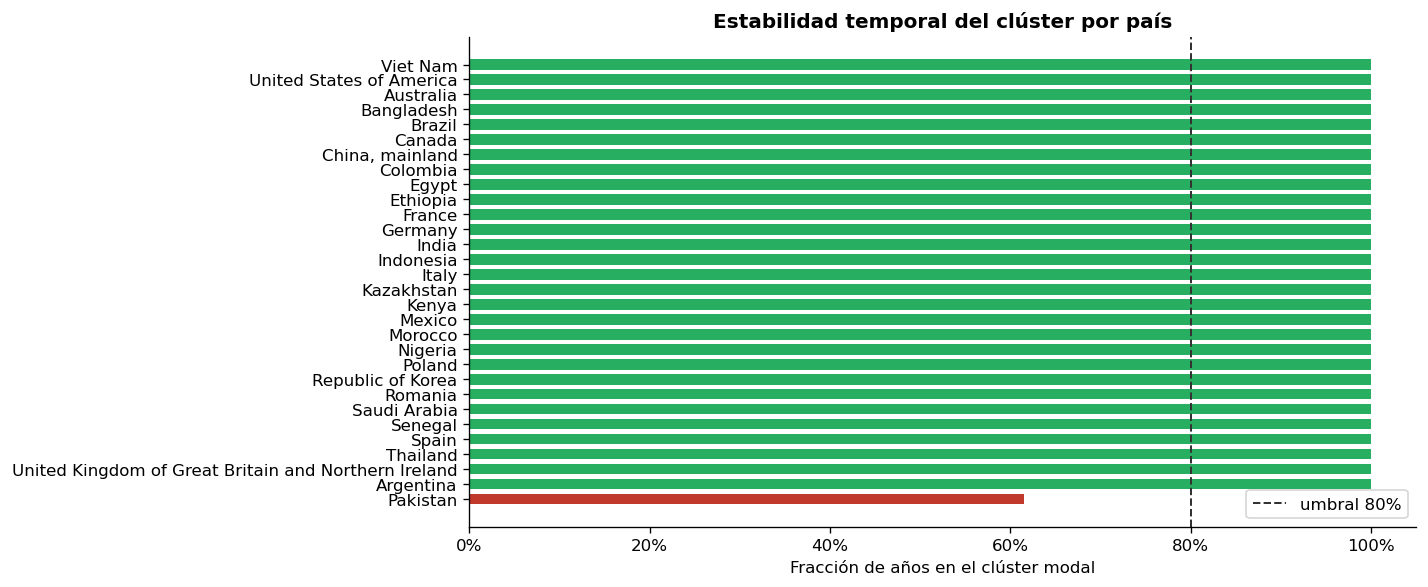

In [12]:
# Gráfico: % tiempo en clúster modal por país
fig, ax = plt.subplots(figsize=(12, 5))
colores = df_estab['pct_en_modal'].apply(lambda x: '#27ae60' if x == 1.0 else ('#f0a500' if x >= 0.80 else '#c0392b'))
ax.barh(df_estab['Area'], df_estab['pct_en_modal'], color=colores, edgecolor='none', height=0.7)
ax.axvline(0.80, color='#333', ls='--', lw=1.2, label='umbral 80%')
ax.set_xlabel('Fracción de años en el clúster modal')
ax.set_title('Estabilidad temporal del clúster por país', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.savefig('../memoria/03_estabilidad_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Export — `processed/03_clusters.parquet`

In [13]:
# Convertir cluster_id a int8 para ahorrar RAM
df['cluster_id'] = df['cluster_id'].astype(np.int8)
df['cluster_nombre'] = df['cluster_nombre'].astype('category')

OUT_PATH = '../processed/03_clusters.parquet'
df.to_parquet(OUT_PATH, index=False)

print(f'Exportado → {OUT_PATH}')
print(f'Shape final: {df.shape}')
print(f'Columnas nuevas: cluster_id, cluster_nombre')
print()
print('Distribución final:')
print(df.groupby(['cluster_id', 'cluster_nombre']).size().rename('n_filas'))
print()

# Verificación
df_check = pd.read_parquet(OUT_PATH)
assert df_check.shape == df.shape, 'ERROR: shape del parquet no coincide'
assert 'cluster_id' in df_check.columns
assert 'cluster_nombre' in df_check.columns
print('✅ Parquet verificado correctamente')

Exportado → ../processed/03_clusters.parquet
Shape final: (390, 15)
Columnas nuevas: cluster_id, cluster_nombre

Distribución final:
cluster_id  cluster_nombre                 
0           Clúster 0 — (pendiente nombrar)    229
            Clúster 1 — (pendiente nombrar)      0
            Clúster 2 — (pendiente nombrar)      0
1           Clúster 0 — (pendiente nombrar)      0
            Clúster 1 — (pendiente nombrar)     13
            Clúster 2 — (pendiente nombrar)      0
2           Clúster 0 — (pendiente nombrar)      0
            Clúster 1 — (pendiente nombrar)      0
            Clúster 2 — (pendiente nombrar)    148
Name: n_filas, dtype: int64

✅ Parquet verificado correctamente


## 10. Resumen de sesión

| Item | Valor |
|------|-------|
| K seleccionado | *rellenar tras ejecutar* |
| Silhouette | *rellenar* |
| Davies-Bouldin | *rellenar* |
| Estabilidad media | *rellenar* |
| Países con cambio de clúster | *rellenar* |
| Output | `processed/03_clusters.parquet` |

**Próximo notebook:** `04_motor_b_lightgbm.ipynb`  
- Input: `03_clusters.parquet`  
- Target (Y): `CO2eq_t_per_capita` + `CO2eq_per_Kcal` (derivada)  
- Predictores (X): vector pct_ + `Food_CPI` (log) + `cluster_id`  
- Métricas: R² ajustado ≥ 0.4, SHAP coherente con teoría